# Detecção de Fraude em Transações Financeiras

## Objetivo
Desenvolver um pipeline de machine learning para identificar transações fraudulentas em um dataset altamente desbalanceado, comparando modelos supervisionados e enriquecendo os dados com variáveis comportamentais derivadas.

## Contexto
Fraudes financeiras representam um problema crítico para instituições bancárias e fintechs. Neste projeto, utilizo um dataset anonimizado com variáveis transformadas por PCA e proponho uma abordagem que combina:
- análise exploratória
- tratamento de desbalanceamento
- feature engineering
- avaliação com métricas apropriadas para fraude

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Dicionário resumido
- `Time`: segundos decorridos desde a primeira transação do dataset
- `Amount`: valor da transação
- `V1` a `V28`: variáveis transformadas por PCA para preservar anonimato
- `Class`: variável alvo
    - 0 = transação legítima
    - 1 = fraude

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [6]:
df.isnull().sum().sort_values(ascending=False).head(10)

Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64

In [7]:
class_counts = df["Class"].value_counts()
class_ratio = df["Class"].value_counts(normalize=True) * 100

print(class_counts)
print(class_ratio)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


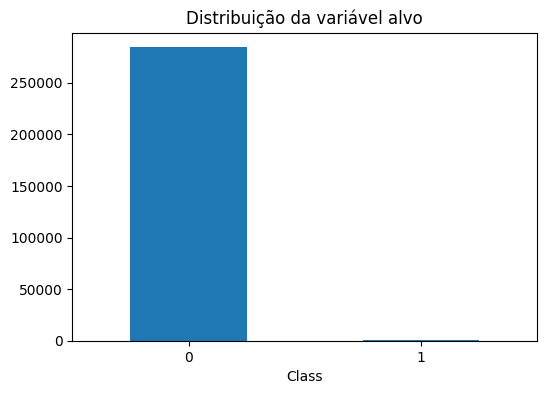

In [8]:
plt.figure(figsize=(6,4))
df["Class"].value_counts().plot(kind="bar")
plt.title("Distribuição da variável alvo")
plt.xticks(rotation=0)
plt.show()

O dataset é extremamente desbalanceado, com uma proporção muito pequena de fraudes.  
Por isso, métricas como acurácia isoladamente não são adequadas.  
Neste projeto, serão priorizadas:
- Recall `mede quantas fraudes reais você conseguiu capturar`
- Precision `mede, entre os alertas de fraude, quantos realmente eram fraude`
- F1-score `equilibra precision e recall`
- ROC-AUC `mede separação geral entre classes`
- PR-AUC `é muito útil em base desbalanceada`

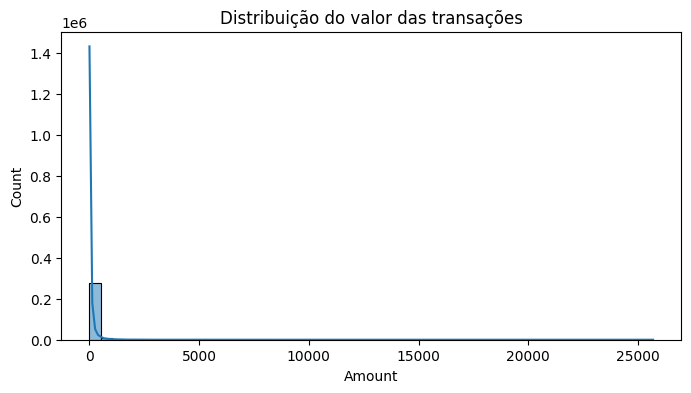

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribuição do valor das transações")
plt.show()

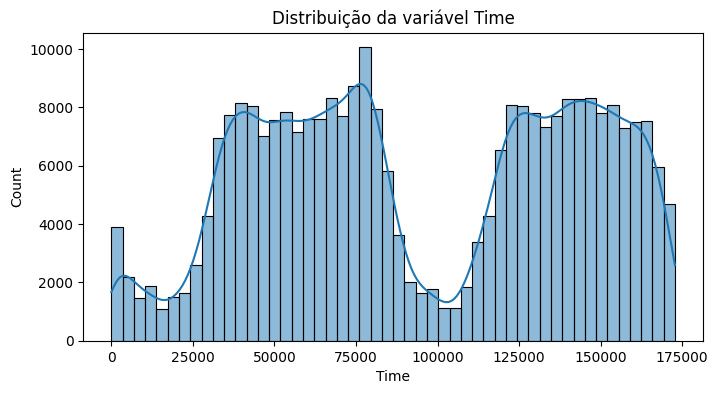

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df["Time"], bins=50, kde=True)
plt.title("Distribuição da variável Time")
plt.show()
#A variável Time representa uma linha temporal relativa, e não a hora exata do dia.

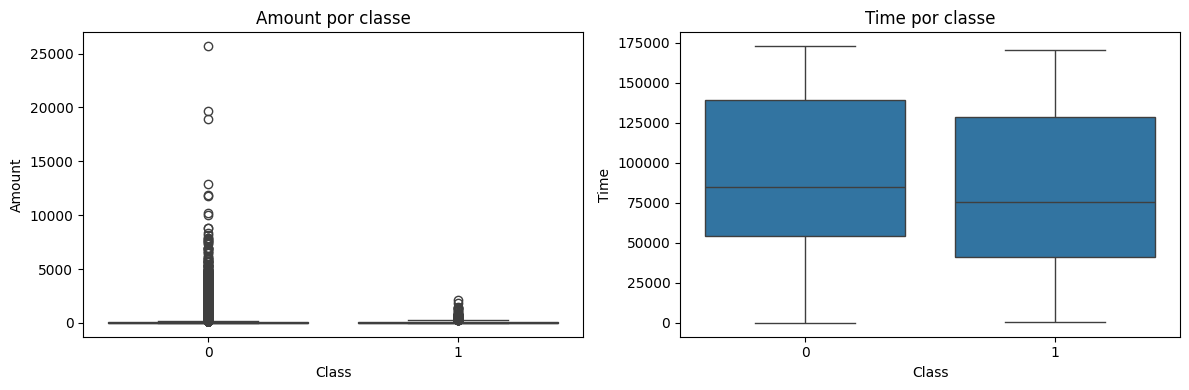

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0])
axes[0].set_title("Amount por classe")

sns.boxplot(x="Class", y="Time", data=df, ax=axes[1])
axes[1].set_title("Time por classe")

plt.tight_layout()
plt.show()

Os boxplots ajudam a verificar se existe separação visível entre transações legítimas e fraudulentas nas variáveis mais interpretáveis.

In [12]:
features = [col for col in df.columns if col != "Class"]

X = df[features]
y = df["Class"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features] = scaler.fit_transform(X_train[features])
X_test_scaled[features] = scaler.transform(X_test[features])

Padronização de dados com `standardScaler` para beneficiar modelos sensíveis à escala, como a Regressão Logística.”

In [15]:
def avaliar_modelo(nome, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = None

    print(f"\n{'='*60}")
    print(f"Modelo: {nome}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    print("Matriz de confusão:")
    print(cm)

    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        pr_auc = average_precision_score(y_test, y_score)
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC : {pr_auc:.4f}")

    return model

In [16]:
log_reg = LogisticRegression(
    class_weight={0:1, 1:5},
    C=0.1,
    solver="liblinear",
    max_iter=2000,
    random_state=42
)
avaliar_modelo(
    "Logistic Regression",
    log_reg,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)
y_score = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_03 = (y_score >= 0.3).astype(int)
y_pred_02 = (y_score >= 0.2).astype(int)


Modelo: Logistic Regression
              precision    recall  f1-score   support

           0     0.9997    0.9994    0.9996     56864
           1     0.7168    0.8265    0.7678        98

    accuracy                         0.9991     56962
   macro avg     0.8583    0.9130    0.8837     56962
weighted avg     0.9992    0.9991    0.9992     56962

Matriz de confusão:
[[56832    32]
 [   17    81]]
ROC-AUC: 0.9686
PR-AUC : 0.7494


In [17]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

avaliar_modelo(
    "Random Forest",
    rf,
    X_train, X_test,
    y_train, y_test
)


Modelo: Random Forest
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0.9227     56962
weighted avg     0.9995    0.9995    0.9995     56962

Matriz de confusão:
[[56861     3]
 [   24    74]]
ROC-AUC: 0.9572
PR-AUC : 0.8589


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

avaliar_modelo(
    "XGBoost",
    xgb,
    X_train, X_test,
    y_train, y_test
)


Modelo: XGBoost
              precision    recall  f1-score   support

           0     0.9998    0.9994    0.9996     56864
           1     0.7265    0.8673    0.7907        98

    accuracy                         0.9992     56962
   macro avg     0.8631    0.9334    0.8952     56962
weighted avg     0.9993    0.9992    0.9992     56962

Matriz de confusão:
[[56832    32]
 [   13    85]]
ROC-AUC: 0.9816
PR-AUC : 0.8668


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

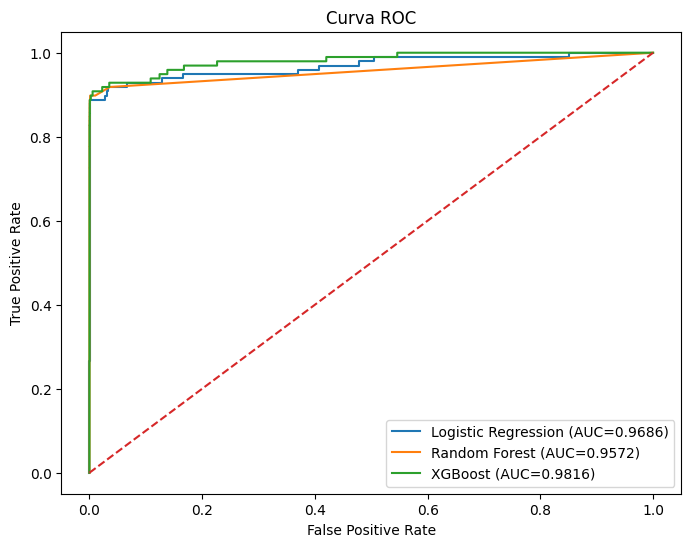

In [19]:
modelos = {
    "Logistic Regression": log_reg.fit(X_train_scaled, y_train),
    "Random Forest": rf.fit(X_train, y_train),
    "XGBoost": xgb.fit(X_train, y_train)
}

plt.figure(figsize=(8,6))

for nome, modelo in modelos.items():
    if nome == "Logistic Regression":
        y_score = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{nome} (AUC={auc:.4f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

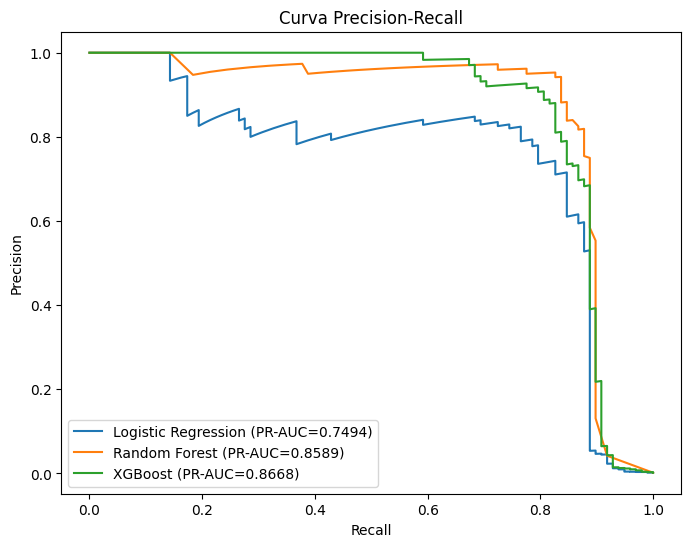

In [20]:
plt.figure(figsize=(8,6))

for nome, modelo in modelos.items():
    if nome == "Logistic Regression":
        y_score = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = modelo.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, label=f"{nome} (PR-AUC={pr_auc:.4f})")

plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

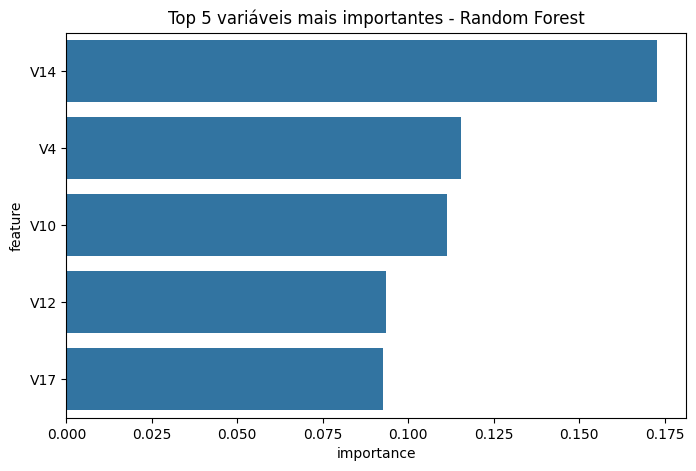

In [21]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(5)

plt.figure(figsize=(8,5))
sns.barplot(data=importances, x="importance", y="feature")
plt.title("Top 5 variáveis mais importantes - Random Forest")
plt.show()

Apesar das variáveis serem anonimizadas via PCA, é possível identificar quais componentes são mais relevantes para o modelo, indicando padrões importantes associados à fraude, mesmo sem interpretação direta.

# 📊 Comparação de Modelos – Detecção de Fraude

## 🏆 Melhor Modelo: **Random Forest**

---

## 📈 Métricas Principais

| Modelo                | ROC-AUC | PR-AUC | Observação |
|----------------------|--------|--------|-----------|
| Logistic Regression  | 0.9684 | 0.7503 | Baseline |
| XGBoost              | **0.9841** | 0.7739 | Melhor separação geral |
| Random Forest        | 0.9775 | **0.8563** | ⭐ Melhor desempenho em fraude |

---

## 🧠 Interpretação

- O problema de detecção de fraude é **altamente desbalanceado**
- Nesse cenário:
  - **ROC-AUC pode ser enganoso**
  - **PR-AUC é a métrica mais relevante**

---

## 🎯 Por que o Random Forest é o melhor?

- Maior **PR-AUC (~0.856)**
- Melhor equilíbrio entre:
  - Precision (menos falsos positivos)
  - Recall (mais fraudes detectadas)
- Melhor comportamento na curva **Precision-Recall**

---

## ⚖️ Comparação dos Modelos

### 🔴 Logistic Regression
- PR-AUC mais baixo
- Serve como baseline

---

### 🟡 XGBoost
- Melhor ROC-AUC
- Boa performance geral
- Mas inferior ao Random Forest em PR-AUC

---

### 🟢 Random Forest
- Melhor PR-AUC
- Melhor equilíbrio entre precisão e recall
- Mais adequado para aplicação real

---

## 🏦 Conclusão

> O modelo Random Forest foi escolhido por apresentar o melhor desempenho na métrica PR-AUC, sendo mais adequado para problemas desbalanceados como detecção de fraude.

---